In [1]:
import os
os.chdir("../")
configs_file = "train_fno"


In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from spinodal_decomp.configs import load_configs
configs = load_configs(configs_file).Configs()

# from corrosion2d.configs import Configs
# configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


Text(0, 0.5, 'Loss')

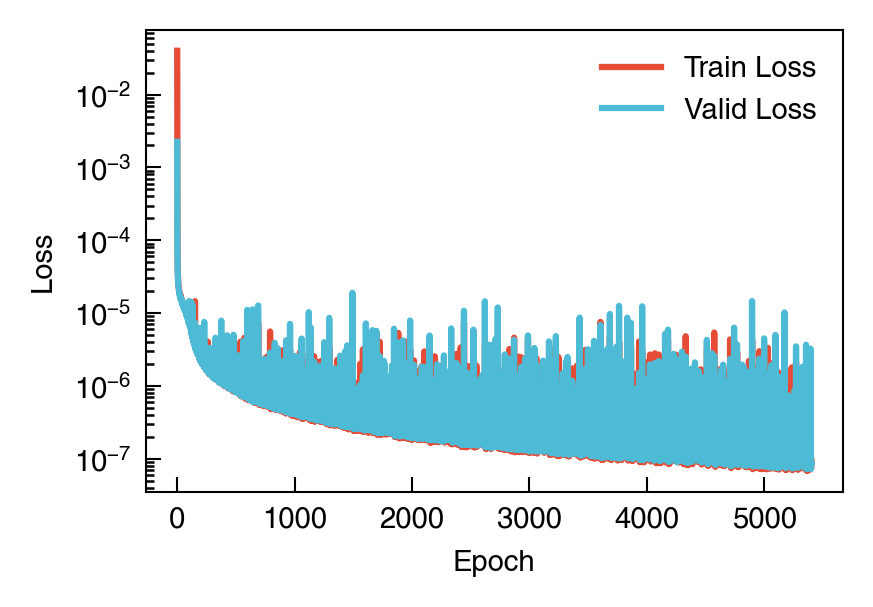

In [3]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")

if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["CHLoss"], label="CH Loss")
    
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

In [4]:
# # read csv loss
# import pandas as pd
# save_dir = configs.save_dir
# loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
# fig, ax = plt.subplots(1, 1, figsize=(3, 2))


# if configs.physical_residual:
#     ax.scatter(loss_df["TrainLoss"], loss_df["CHLoss"], 
#                label="CH Loss", s=1, c=loss_df["Epoch"]
#                )
#     ax.plot([1e-8, 1], [1e-8, 1])
    
# ax.legend()
# ax.set_yscale("log")
# ax.set_xscale("log")
# ax.set_xlabel("TrainLoss")
# ax.set_ylabel("CHLoss")
# ax.set_aspect("equal")

Text(0, 0.5, 'MSE')

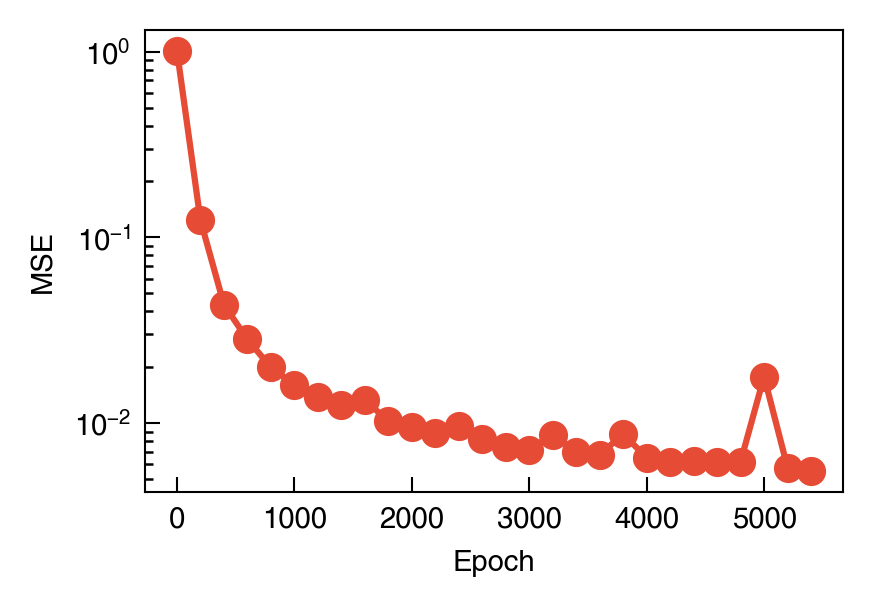

In [5]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")


In [6]:
# from model import model1d
from spinodal_decomp.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
weight = os.path.join(save_dir, f"epoch_4000.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [7]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((625, 4, 64, 64), (625, 1, 64, 64))

In [8]:
Xs[0, 1, ...]

array([[0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749],
       [0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749],
       [0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749],
       ...,
       [0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749],
       [0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749],
       [0.71969749, 0.71969749, 0.71969749, ..., 0.71969749, 0.71969749,
        0.71969749]], shape=(64, 64))

MSE: 5.641422973212684e-08
MSE: 1.234926383375523e-08
MSE: 1.7241848127014237e-07
MSE: 1.4920658486516913e-07


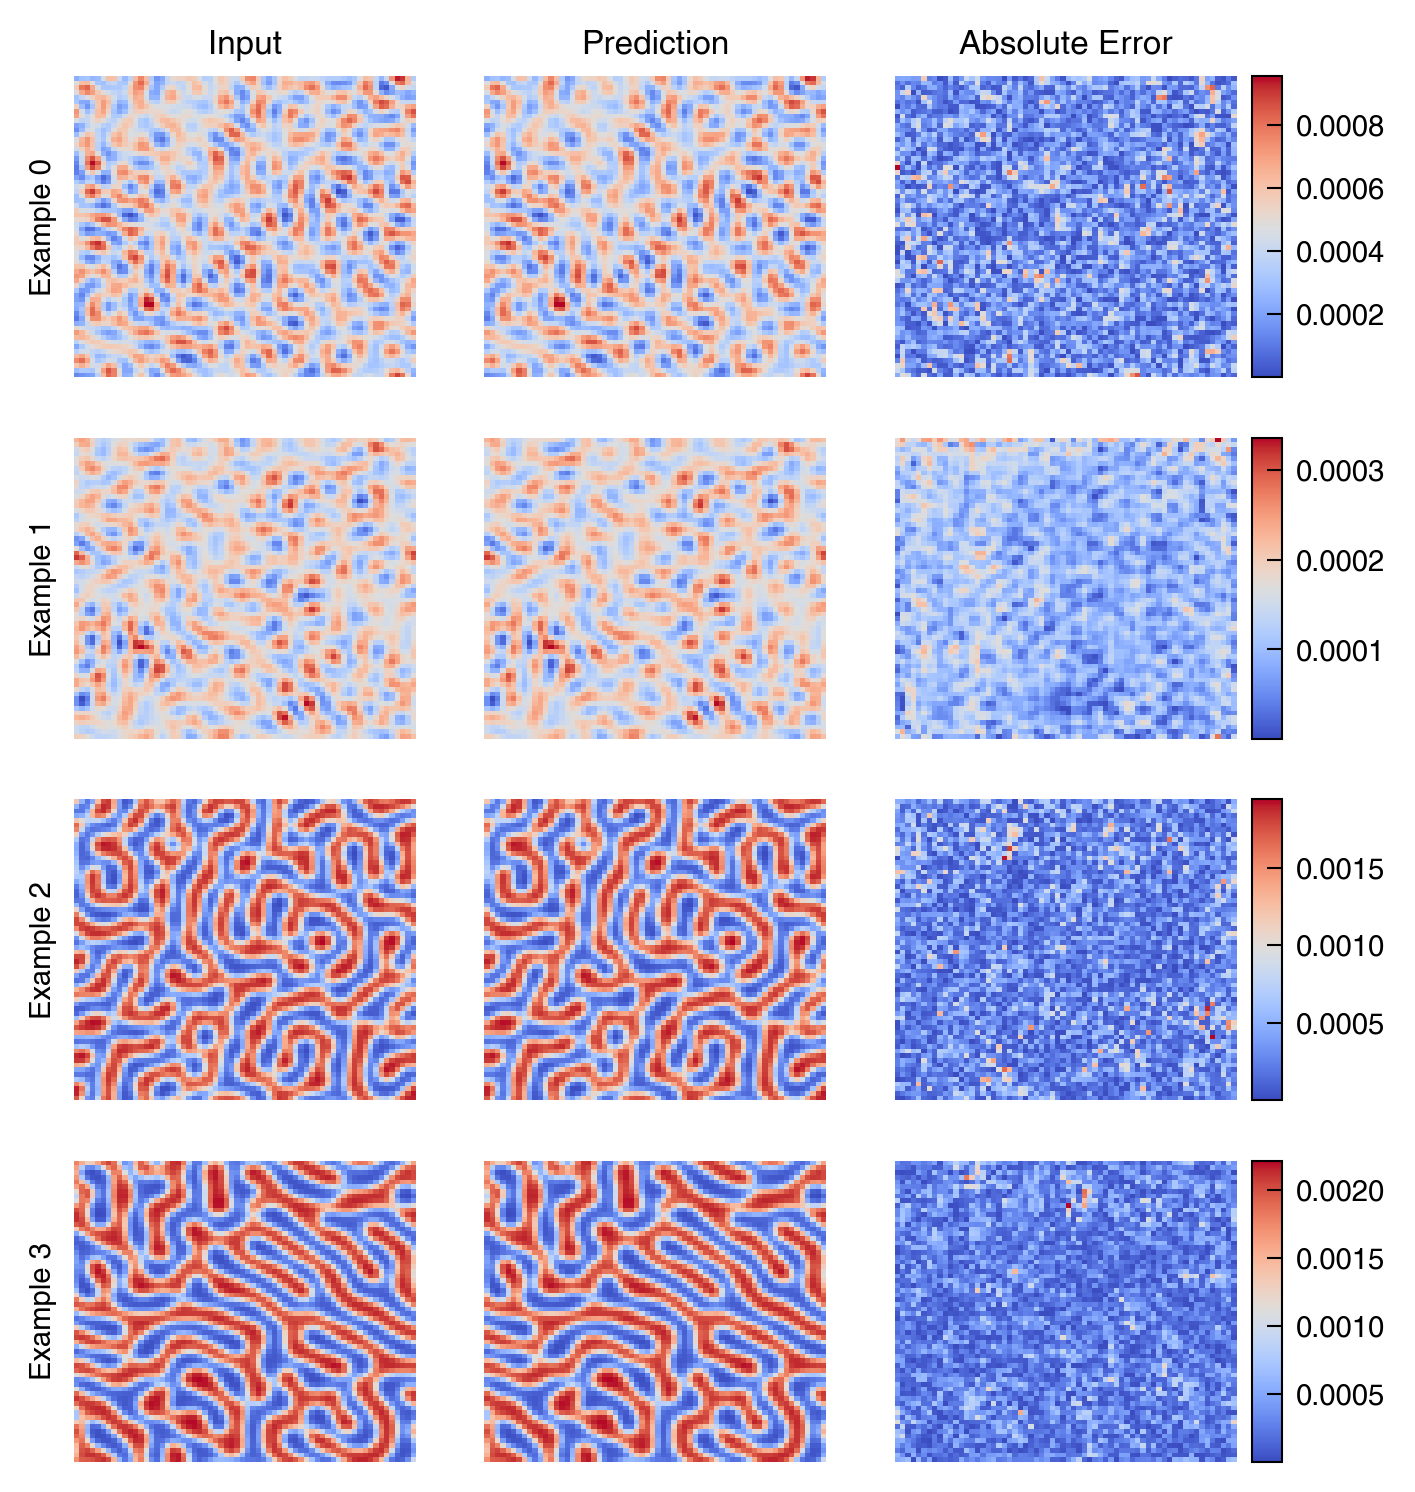

In [9]:
num_examples = 4
import numpy as np
# random_indices = np.random.choice(Xs.shape[0], num_examples, replace=False)
random_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(num_examples, 3, figsize=(5, 1.5 * num_examples))
xs_examples = Xs[random_indices]
ys_examples = Ys[random_indices]
# ks_examples = ks[random_indices]
y_pred_examples = jax.vmap(model.forward)(xs_examples)
component = 0

for i, idx in enumerate(random_indices):
    ax = axes[i, 0]
    ax.pcolormesh(meshesx, meshesy, ys_examples[i, component, :, :], shading='auto', cmap='coolwarm',)
    ax.set_axis_off()
    # ax.set_ylabel(f"Example {idx}", rotation=0, labelpad=20, fontsize=8, va='center')
    ax.text(-0.05, 0.5, f"Example {idx}", rotation=90, va='center', ha="right", transform=ax.transAxes,)
    if i == 0:
        ax.text(0.5, 1.05, "Input", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 1]
    ax.pcolormesh(meshesx, meshesy, y_pred_examples[i, component, :, :], shading='auto', cmap='coolwarm', )
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Prediction", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 2]
    diff = jnp.abs(ys_examples[i, component, :, :] - y_pred_examples[i, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=100, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Absolute Error", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax_bar = fig.add_axes([ax.get_position().x1 + 0.01,
                           ax.get_position().y0,
                           0.02,
                           ax.get_position().height])
    fig.colorbar(diff_ax, cax=ax_bar)
    print(f"MSE: {jnp.mean(diff**2)}")
# fig.tight_layout()

## Uncomment the following lines to start fine-tuning 

In [10]:
jax.config.update("jax_enable_x64", True)
def ch_loss_rollout(model, u0s, ms, meshes, steps, ys, dx, dy, dt, **kwargs):
    u0s = u0s.astype(jnp.float64)
    ms = ms.astype(jnp.float64)
    meshes = meshes.astype(jnp.float32)
    ys = ys.astype(jnp.float64)
    nx, ny = u0s.shape[-2], u0s.shape[-1]
    dx_phys = dx * configs.Lc
    dy_phys = dy * configs.Lc
    kx = jnp.fft.fftfreq(nx, d=dx_phys) * 2 * jnp.pi
    ky = jnp.fft.fftfreq(ny, d=dy_phys) * 2 * jnp.pi
    KX, KY = jnp.meshgrid(kx, ky, indexing='xy')
    K2 = KX**2 + KY**2
    K4 = K2**2
    
    # 修正：移除多余的 mesh 参数，使其与 vmap 的 in_axes=(0,0) 匹配
    def auto_reg_fn(u0, m):
        m_channel = jnp.full((1, meshes.shape[1], meshes.shape[2]), m)

        def scan_fn(carry, _):
            u_prev = jax.lax.stop_gradient(carry)
            inputs = jnp.concatenate([u_prev, m_channel, meshes], axis=0) # (in_channels, nx, ny)
            u_next = model.forward(inputs)
            return u_next, u_next
        
        _, u_preds = jax.lax.scan(
            scan_fn,
            u0,
            None,
            length=steps
        )
        return u_preds  # (steps, out_channels, nx, ny)


    def rollout_residual(u0s, ys, dt):

        u_preds = jax.vmap(auto_reg_fn, in_axes=(0,0))(u0s.astype(jnp.float32), ms.astype(jnp.float32)) # (batch, steps, channels, nx, ny)
        u_preds = u_preds.astype(jnp.float64)
        cs = u_preds[:, :, 0, :, :]  # batch, steps, nx, ny
        c0s = u0s[:, 0, :, :] # batch, nx, ny
        c0s = c0s[:, None, ...] # (batch, 1, nx, ny)
        c0s = jnp.concatenate(
            [c0s, u_preds[:, :-1, 0, :, :]], axis=1
        ) # (batch, steps, nx, ny)
        
        # 我们只优化从 c0 -> c 的转换过程，而不优化 c0 本身
        c0s = jax.lax.stop_gradient(c0s)
        mse_error = jnp.mean((cs - ys)**2)

        def one_step_residual(c0, c, M, dt):
            # use spectral type governing equations
            dt_unit = dt * configs.Tc
            c0_hat = jnp.fft.fft2(c0) 
            c_hat = jnp.fft.fft2(c)
            lhs_hat = c_hat - c0_hat
            lambda_param = configs.lambda_param
            
            # Calculate nonlinear terms f'(c) = c^3 - c for both time steps
            f_prime_c = c**3 - c
            f_prime_c0 = c0**3 - c0
            
            f_prime_c_hat = jnp.fft.fft2(f_prime_c)
            f_prime_c0_hat = jnp.fft.fft2(f_prime_c0)

            # Spectral derivatives: laplacian -> -K2, bi-laplacian -> K4
            term1_hat = -0.5 * M * K2 * (f_prime_c_hat + f_prime_c0_hat) * dt_unit
            term2_hat = -0.5 * M * lambda_param * K4 * (c_hat + c0_hat) * dt_unit
            
            rhs_hat = term1_hat + term2_hat
            residual_hat = lhs_hat - rhs_hat
            residual = jnp.fft.ifft2(residual_hat).real
            return residual # (step, nx, ny)
    
        residuals = jax.vmap(one_step_residual, in_axes=(0,0,0,None))(
            c0s, cs, ms, dt
        )  # (batch, steps, nx, ny)
        return residuals, mse_error
    residuals, mse_error = rollout_residual(u0s, ys, dt)
    # residuals_time_segmented = jnp.mean(residuals, axis=(0,2,3))  # (steps,)
    # cumulative_loss = jnp.cumsum(residuals_time_segmented[:-1])
    # weights = jnp.concatenate([jnp.array([1.0]), jnp.exp(-500 * cumulative_loss)])  # (steps,)
    # weights = jax.lax.stop_gradient(weights)
    # loss = jnp.mean(weights[None, :, None, None] * (residuals**2))
    loss = jnp.mean(residuals**2)
    assert loss.dtype == jnp.float64, "Loss is not float64"
    loss = loss.astype(jnp.float32)
    mse_error = mse_error.astype(jnp.float32)
    return loss, (mse_error,)


In [11]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
# test_solutions = jnp.load(os.path.join("/root/autodl-tmp/data/spinodal_decomp_spectra/test_extra", 
#                                        "solutions_grid.npy"))
test_ms = jnp.load(os.path.join(configs.test_data_dir, "M_values.npy"))
start = 0
steps = 100
u0 = test_solutions[:, start, :, :]
y_test = test_solutions[:, start+1:start+1+steps, :, :]


fine_tune_epochs = 2500
loss_fn = partial(
    ch_loss_rollout,
    meshes=meshes,
    steps=steps,
    dx=1/64,
    dy=1/64,
    dt=dt,
)

import optax
optimizer = optax.adam(1e-5)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))



# 使用 filter_jit 包装更新步，提高效率并处理 PyTree
@eqx.filter_jit
def make_step(model, opt_state, u0s, ms, ys):
    (loss, (mse_error,)), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        model, u0s=u0s, ms=ms, ys=ys)
    
    # 建议：添加梯度裁剪以防止梯度爆炸
    grads = jax.tree.map(lambda x: jnp.nan_to_num(x), grads) # 防止 NaN 传播
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, mse_error


# model use float32 for speed
model = jax.tree.map(lambda x: x.astype(jnp.float32) if isinstance(x, jnp.ndarray) else x, model)

fine_tune_losses = []
mse_errors = []
model_best = model
best_mse = jnp.inf
for epoch in range(fine_tune_epochs):
    model, opt_state, loss, mse_error = make_step(
        model, 
        opt_state, 
        test_solutions[:, start, :, :], 
        test_ms,
        y_test[:, :, 0, ...]
    )
    if mse_error < best_mse:
        best_mse = mse_error
        model_best = model

    print(f"Fine-tune Epoch {epoch}, CH Loss: {loss:.4e}, MSE Error: {mse_error:.4e}, ")
    fine_tune_losses.append(loss)
    mse_errors.append(mse_error)
    if epoch % 50 == 0:
        # save model
        save_path = os.path.join(save_dir, f"fine_tuned_epoch_{epoch}.eqx")
        eqx.tree_serialise_leaves(save_path, model)


2025-12-23 20:32:37.093822: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.76GiB (rounded to 13703294976)requested by op 
2025-12-23 20:32:37.094063: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] **************______________________________________________________________________________________
E1223 20:32:37.094113    5110 pjrt_stream_executor_client.cc:3026] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 13703294912 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 13703294912 bytes.

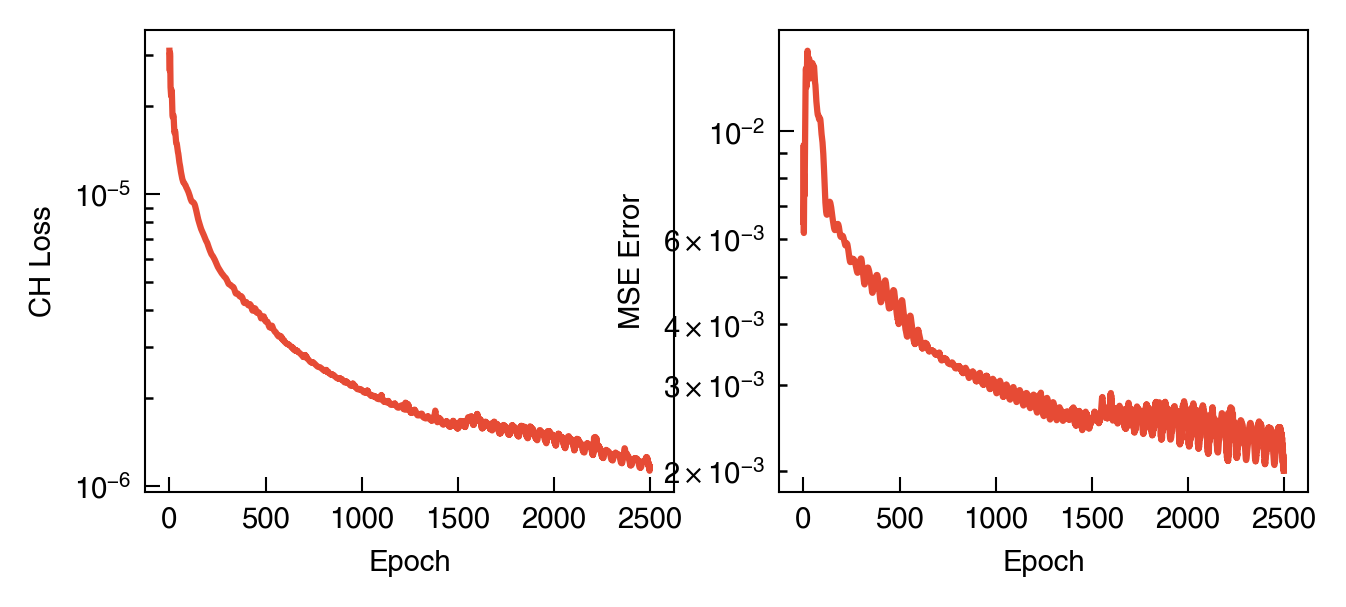

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2))
ax = axes[0]
ax.plot(jnp.arange(fine_tune_epochs), fine_tune_losses, label="Fine-tune CH Loss")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("CH Loss")

# ax = axes[1]
ax.plot(jnp.arange(fine_tune_epochs), mse_errors, label="MSE Error")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Error")
jnp.save(os.path.join(save_dir, "fine_tune_losses.npy"), fine_tune_losses)
jnp.save(os.path.join(save_dir, "fine_tune_mse_errors.npy"), mse_errors)

# # save model
# eqx.tree_serialise_leaves(
#     os.path.join(save_dir, f"epoch_finetuned.eqx"),
#     model_best)

In [ ]:
jax.config.update("jax_enable_x64", False)

In [ ]:
weight = os.path.join(save_dir, f"epoch_finetuned.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [ ]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ms = jnp.load(os.path.join(configs.test_data_dir, "M_values.npy"))
start = 0
steps = 100
u0 = test_solutions[:, start, :, :]
y_test = test_solutions[:, start+1:start+1+steps, :, :]

auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds = jax.vmap(auto_reg_fn, in_axes=(0,0))(u0, test_ms)
u0.shape, test_ms.shape, u_preds.shape

((5, 1, 64, 64), (5,), (5, 100, 1, 64, 64))

In [ ]:
idxs = [0, 24, 49, 74, 99]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0
fig, axes = plt.subplots(3, len(idxs), figsize=(1.3 * len(idxs), 3.8),)
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={(idx+1)*dt*configs.Tc:.2e} s", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

NameError: name 'meshes' is not defined

Text(0, 0.5, 'Free Energy F')

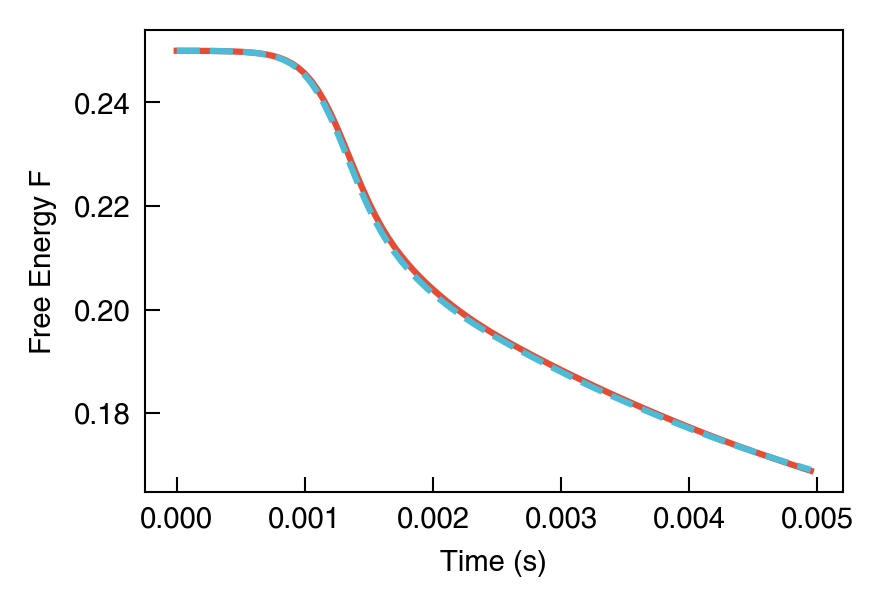

In [ ]:
nx = 64
ny = 64
lx = 1.0
ly = 1.0
dx = lx / nx
dy = ly / ny
kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=lx/nx)
ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=ly/ny)
KX, KY = jnp.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2

def compute_F(c):

    grad_c_x_hat = 1j * KX * jnp.fft.fft2(c)
    grad_c_y_hat = 1j * KY * jnp.fft.fft2(c)
    grad_c_x = jnp.fft.ifft2(grad_c_x_hat).real
    grad_c_y = jnp.fft.ifft2(grad_c_y_hat).real
    grad_c_sq = grad_c_x**2 + grad_c_y**2
    f_c = (configs.lambda_param / 2) * grad_c_sq + (1/4) * (c**2 - 1)**2
    F_c = jnp.sum(f_c) * (dx * dy)
    return F_c

Fc_test = jax.vmap(compute_F)(y_test[example_th])
Fc_pred = jax.vmap(compute_F)(u_preds[example_th])
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(jnp.arange(steps) * dt * configs.Tc, Fc_test, label="Ground Truth")
ax.plot(jnp.arange(steps) * dt * configs.Tc, Fc_pred, label="Prediction", linestyle='--')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Free Energy F")

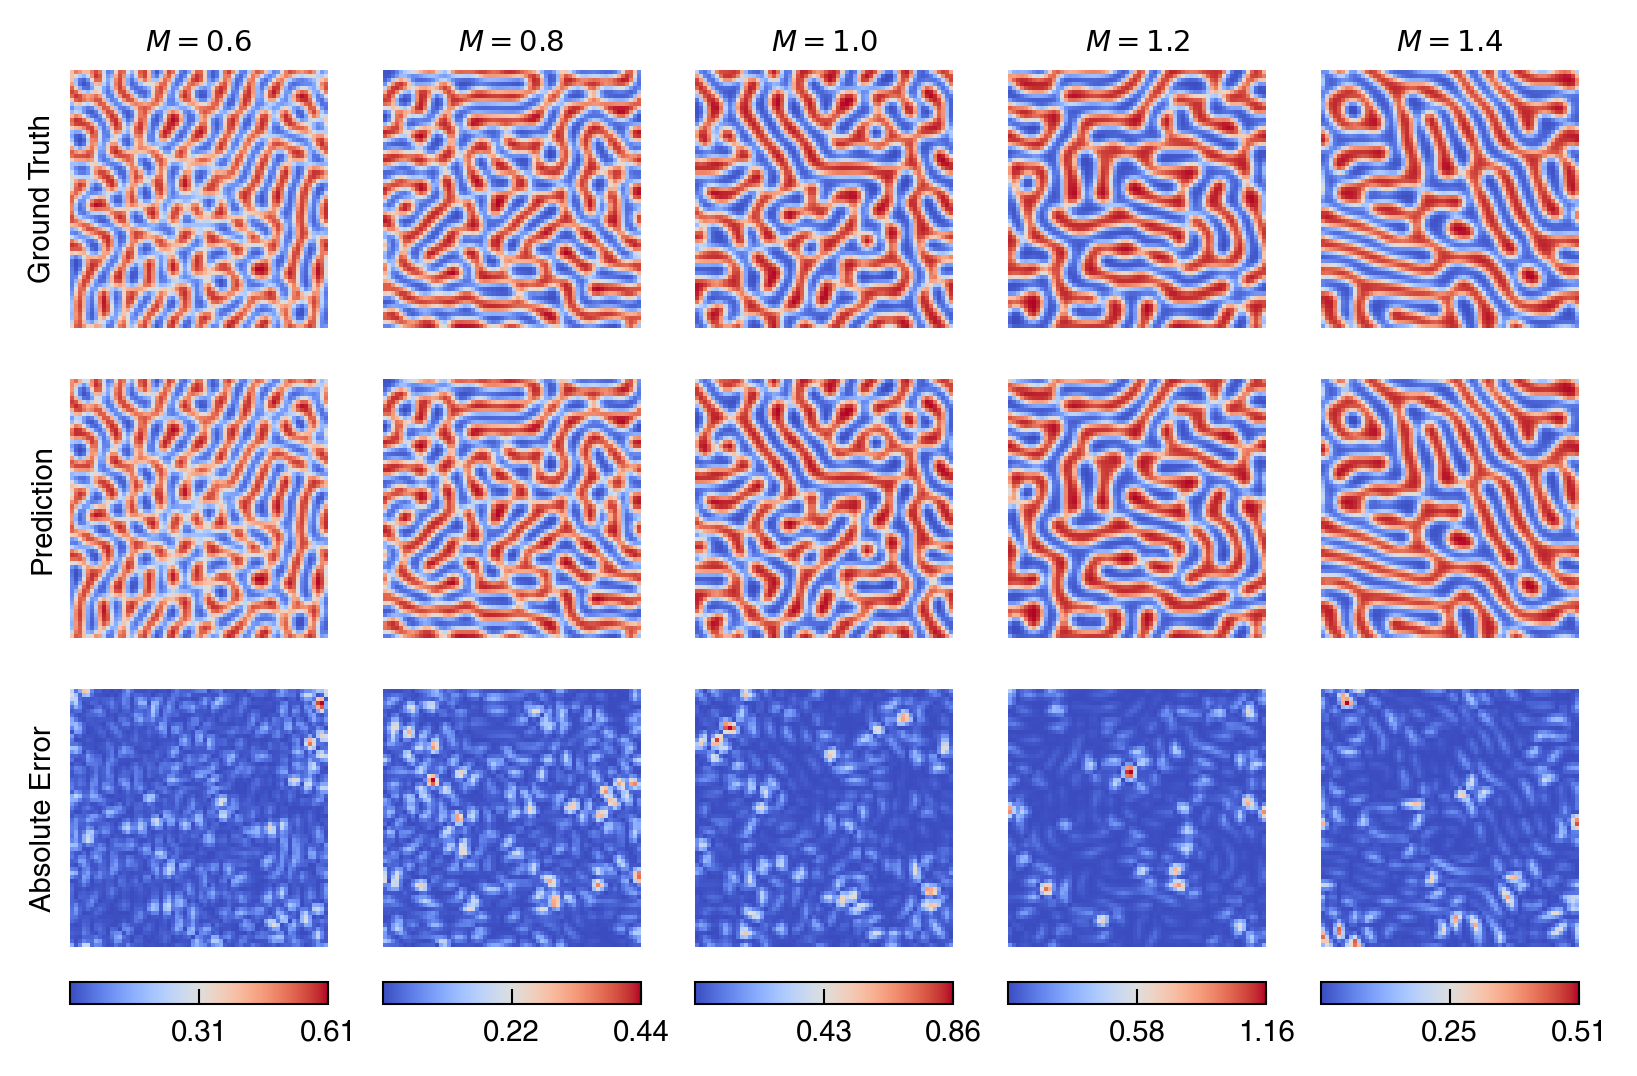

In [ ]:
meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0,1,2,3,4]
idx = -1
component = 0
fig, axes = plt.subplots(3, len(example_ths), figsize=(1.3 * len(example_ths), 3.8),)
for i, example_th in enumerate(example_ths):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, fr"$M={test_ms[example_th]:.1f}$",
             ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

In [ ]:
mse = jnp.mean((y_test - u_preds)**2)
print(f"Test MSE after fine-tuning: {mse:.4e}")

Test MSE after fine-tuning: 2.1062e-03


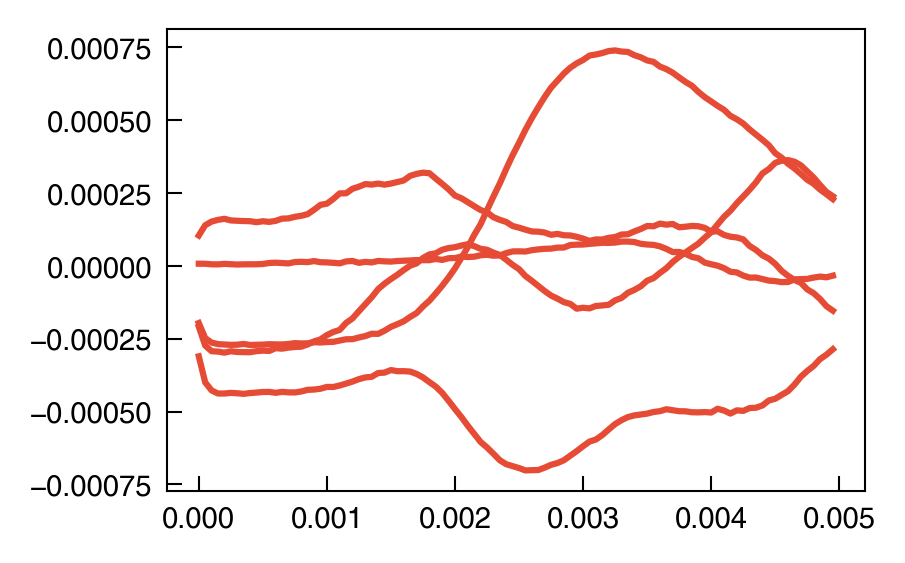

In [ ]:
# conservation validation for c
component = 0
num_tests = y_test.shape[0]
mass = jnp.mean(y_test[:, :, component, :, :], axis=(-1, -2)) 
mass_pred = jnp.mean(u_preds[:, :, component, :, :], axis=(-1, -2))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
time_points = jnp.arange(steps) * dt * configs.Tc

for i in range(num_tests):
    ax.plot(time_points, mass_pred[i, :], color='C0', )
    # ax.plot(time_points, mass[i, :], color='C1',)
    # ax.plot(time_points, diff[i] )



In [ ]:
# # acc logs
# test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))

# u0 = test_solutions[:, 0, :, :]
# y_test = test_solutions[:, 1:, :, :]
# epochs = jnp.arange(0, 2001, 200)
# mse_list = []
# for epoch in epochs:
#     weight = os.path.join(save_dir, f"epoch_{epoch}.eqx")
#     model = eqx.tree_deserialise_leaves(weight, model_skeleton)

#     auto_reg_fn = partial(
#         model.auto_reg,
#         meshes=meshes,
#         steps=100
#     )
#     u_preds = jax.vmap(auto_reg_fn)(u0)

#     mse = jnp.mean((y_test - u_preds) ** 2,)
#     mse_list.append(mse)

# fig, ax = plt.subplots(1, 1, figsize=(3, 2))
# ax.plot(epochs, mse_list, marker='o')
# ax.set_yscale("log")
# ax.set_xlabel("Epoch")
# ax.set_ylabel("MSE on test set")
# plt.tight_layout()

# # save test mse
# path = os.path.join(save_dir, "test_mse.npy")
# jnp.save(path, jnp.array(mse_list))
# l2 = jnp.linalg.norm(y_test - u_preds) / jnp.linalg.norm(y_test)
# l2


Text(0, 0.5, 'Relative $L_2$ Error')

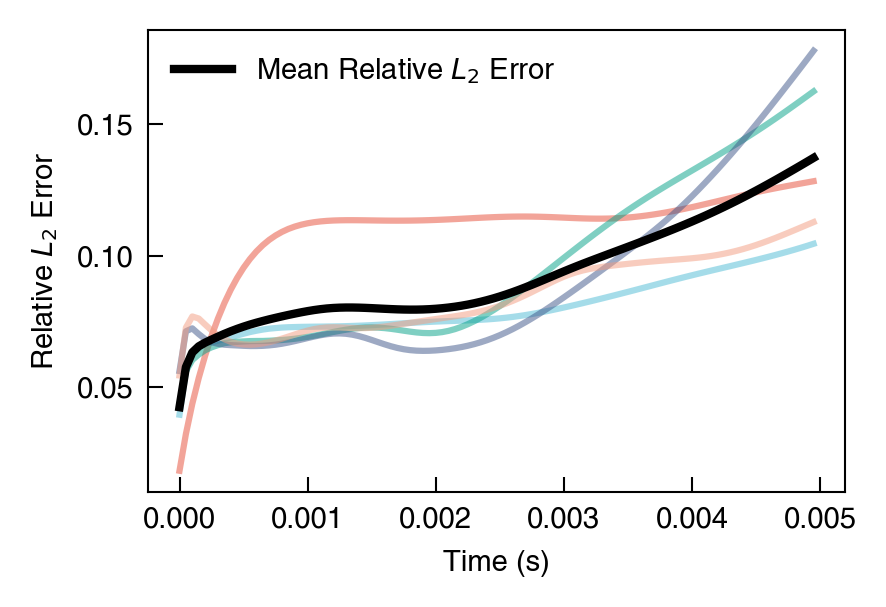

In [ ]:
# step-wise error


fig, ax = plt.subplots(1, 1, figsize=(3, 2))
time_points = jnp.arange(steps) * dt * configs.Tc
for i in range(y_test.shape[0]):
    step_pred = u_preds[i, :, 0, :, :]
    step_true = y_test[i, :, 0, :, :]
    step_error = jnp.linalg.norm(step_true - step_pred, axis=(-1,-2)) / jnp.linalg.norm(step_true, axis=(-1,-2))
    ax.plot(time_points, step_error, alpha=0.5)
mean_error = jnp.mean(jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2)), axis=0)
ax.plot(time_points, mean_error, color='black', linewidth=2, label='Mean Relative $L_2$ Error')
ax.legend()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Relative $L_2$ Error")

In [ ]:
y_test.shape

(5, 100, 1, 64, 64)

In [ ]:
jax.config.update("jax_enable_x64", False)

In [ ]:
nx = 64
ny = 64
lx = 1.0
ly = 1.0
dx = lx / nx
dy = ly / ny
kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=dx).astype(jnp.float64)
ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=dy).astype(jnp.float64)
KX, KY = jnp.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2
K4.max()

/root/miniconda3/envs/jaxenv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.


Array(6.5370143e+09, dtype=float32)

In [ ]:
# xs_examples = xs_examples
# ys_examples = ys_examples
# y_pred_examples = y_pred_examples
# c0 = xs_examples[:, 0, :, :]
# c = y_pred_examples[:, 0, :, :]
Xs = Xs.astype(jnp.float32)
preds = jax.vmap(model.forward)(Xs)
c0 = Xs[:100, 0, :, :].astype(jnp.float64)
c = Ys[:100, 0, :, :].astype(jnp.float64)

print(c.shape, c0.shape)

# 重新获取原始 dt
dt =( times[1] - times[0]) * configs.Tc

# 1. 转到频域
c0_hat = jnp.fft.fft2(c0)
c_hat = jnp.fft.fft2(c)

# 2. 计算 LHS: dc/dt * dt = c - c0
lhs_hat = (c_hat - c0_hat)

# 3. 计算 RHS
M = 1.0
lambda_param = 0.01**2

# 非线性项 f'(c) = c^3 - c
f_prime_c = c**3 - c
f_prime_c0 = c0**3 - c0

f_prime_c_hat = jnp.fft.fft2(f_prime_c)
f_prime_c0_hat = jnp.fft.fft2(f_prime_c0)

# Term 1: M * laplacian(f'(c) + f'(c0)) * 0.5 * dt
# laplacian -> -K2
term1_hat = -0.5 * M * K2 * (f_prime_c_hat + f_prime_c0_hat) * dt

# Term 2: - M * lambda * bi-laplacian(c + c0) * 0.5 * dt
# bi-laplacian -> K4
term2_hat = -0.5 * M * lambda_param * K4 * (c_hat + c0_hat) * dt

rhs_hat = term1_hat + term2_hat

# 4. 计算残差 (LHS - RHS)
res_hat = lhs_hat - rhs_hat
residual = jnp.fft.ifft2(res_hat).real


# 打印统计
print(f"Residual Max: {jnp.max(jnp.abs(residual))}")
print(f"Residual Mean: {jnp.mean(jnp.abs(residual))}")
print(f"Residual Std: {jnp.std(residual)}")

# 取绝对值用于后续绘图
residual = jnp.abs(residual)


(100, 64, 64) (100, 64, 64)
Residual Max: 0.030192185193300247
Residual Mean: 0.0023759466130286455
Residual Std: 0.0036780701484531164


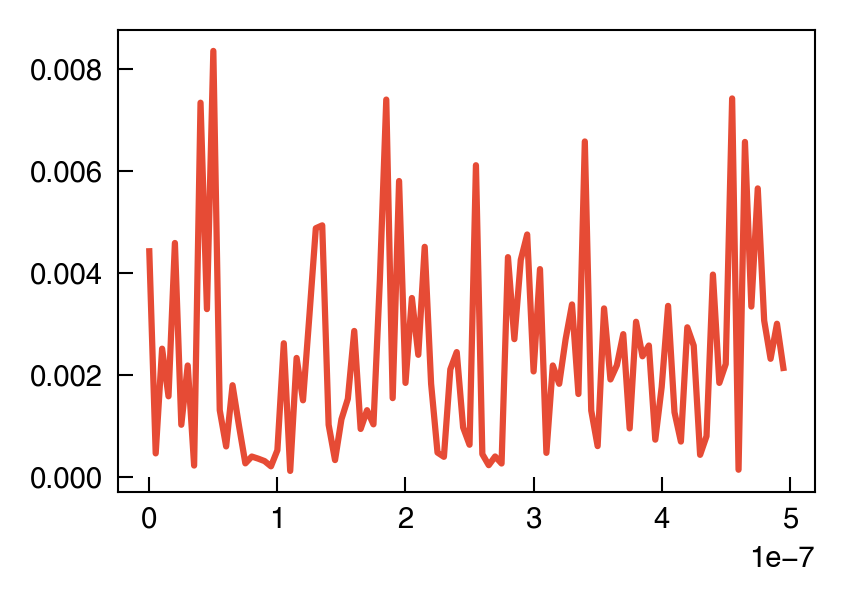

In [ ]:
residual = jnp.mean(residual, axis=(-1, -2))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
time_points = jnp.arange(steps) * dt * configs.Tc
ax.plot(time_points, residual)